# PhishGuard ML Subsystem — Exploratory Data Analysis

**Dataset:** ISCX-URL (Canadian Institute for Cybersecurity)  
**Objective:** Analyze URL-based features to reduce dimensionality, remove redundancy, and generate modeling insights.  
**Classification:** Multi-class (benign, phishing, malware, defacement, spam)  

---

## Step 1 — Environment Setup & Imports

In [2]:
# ============================================================
# Step 1: Environment Setup & Imports
# ============================================================

# Core
import pandas as pd
import numpy as np
import json
import os
import warnings

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine Learning (full package)
import sklearn

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Plot configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Pandas display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

# Paths
DATA_PATH = os.path.join('..', 'Data', 'All.csv')
REPORTS_DIR = os.path.join('..', 'reports')
PLOTS_DIR = os.path.join(REPORTS_DIR, 'plots')

# Create output directories
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'pandas:       {pd.__version__}')
print(f'numpy:        {np.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'seaborn:      {sns.__version__}')
print()
print(f'Data path:    {os.path.abspath(DATA_PATH)}')
print(f'Reports dir:  {os.path.abspath(REPORTS_DIR)}')
print(f'Plots dir:    {os.path.abspath(PLOTS_DIR)}')
print(f'Data exists:  {os.path.exists(DATA_PATH)}')
print('\n--- Setup complete ---')

pandas:       3.0.3
numpy:        2.4.4
scikit-learn: 1.8.0
seaborn:      0.13.2

Data path:    d:\ML-CC\Data\All.csv
Reports dir:  d:\ML-CC\reports
Plots dir:    d:\ML-CC\reports\plots
Data exists:  True

--- Setup complete ---


---
## Step 2 — Data Loading & Initial Inspection

In [3]:
# ============================================================
# Step 2: Load dataset
# ============================================================

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage:  {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Dataset shape: 36,707 rows x 80 columns
Memory usage:  25.26 MB


In [4]:
# Column names
print('All columns:\n')
for i, col in enumerate(df.columns):
    print(f'  [{i:2d}] {col:40s}  ({df[col].dtype})')

All columns:

  [ 0] Querylength                               (int64)
  [ 1] domain_token_count                        (int64)
  [ 2] path_token_count                          (int64)
  [ 3] avgdomaintokenlen                         (float64)
  [ 4] longdomaintokenlen                        (int64)
  [ 5] avgpathtokenlen                           (float64)
  [ 6] tld                                       (int64)
  [ 7] charcompvowels                            (int64)
  [ 8] charcompace                               (int64)
  [ 9] ldl_url                                   (int64)
  [10] ldl_domain                                (int64)
  [11] ldl_path                                  (int64)
  [12] ldl_filename                              (int64)
  [13] ldl_getArg                                (int64)
  [14] dld_url                                   (int64)
  [15] dld_domain                                (int64)
  [16] dld_path                                  (int64)
  [17] dld_fi

In [5]:
# First 5 rows
df.head()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,ldl_domain,ldl_path,ldl_filename,ldl_getArg,dld_url,dld_domain,dld_path,dld_filename,dld_getArg,urlLen,domainlength,pathLength,subDirLen,fileNameLen,this.fileExtLen,ArgLen,pathurlRatio,ArgUrlRatio,argDomanRatio,domainUrlRatio,pathDomainRatio,argPathRatio,executable,isPortEighty,NumberofDotsinURL,ISIpAddressInDomainName,CharacterContinuityRate,LongestVariableValue,URL_DigitCount,host_DigitCount,Directory_DigitCount,File_name_DigitCount,Extension_DigitCount,Query_DigitCount,URL_Letter_Count,host_letter_count,Directory_LetterCount,Filename_LetterCount,Extension_LetterCount,Query_LetterCount,LongestPathTokenLength,Domain_LongestWordLength,Path_LongestWordLength,sub-Directory_LongestWordLength,Arguments_LongestWordLength,URL_sensitiveWord,URLQueries_variable,spcharUrl,delimeter_Domain,delimeter_path,delimeter_Count,NumberRate_URL,NumberRate_Domain,NumberRate_DirectoryName,NumberRate_FileName,NumberRate_Extension,NumberRate_AfterPath,SymbolCount_URL,SymbolCount_Domain,SymbolCount_Directoryname,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5000,14,4.4000,4,8,3,0,0,0,0,0,0,0,0,0,0,58,25,26,26,13,1,2,0.4483,0.0345,0.0800,0.4310,1.0400,0.0769,0,-1,5,-1,0.6000,-1,1,0,0,0,1,-1,47,22,8,13,0,-1,13,14,13,5,-1,0,0,3,0,2,-1,0.0172,0.0000,0.0000,0.0667,1.0000,-1.0000,8,3,2,1,0,-1,0.7263,0.7845,0.8949,0.8506,NaN,-1.0000,Defacement
1,0,4,5,5.5000,14,6.0000,4,12,4,0,0,0,0,0,0,0,0,0,0,66,25,34,34,2,2,2,0.5152,0.0303,0.0800,0.3788,1.3600,0.0588,0,-1,4,-1,0.6000,-1,0,0,0,0,0,-1,56,22,8,13,9,-1,13,14,13,5,-1,0,0,4,0,1,-1,0.0000,0.0000,0.0000,0.0000,NaN,-1.0000,8,3,3,0,0,-1,0.6886,0.7845,0.8147,0.8598,0.0000,-1.0000,Defacement
2,0,4,5,5.5000,14,5.8000,4,12,5,0,0,0,0,0,0,0,0,0,0,65,25,33,33,2,2,2,0.5077,0.0308,0.0800,0.3846,1.3200,0.0606,0,-1,4,-1,0.6000,-1,0,0,0,0,0,-1,55,22,8,13,8,-1,13,14,13,5,-1,0,0,4,0,1,-1,0.0000,0.0000,0.0000,0.0000,NaN,-1.0000,8,3,3,0,0,-1,0.6950,0.7845,0.8147,0.8019,0.0000,-1.0000,Defacement
3,0,4,12,5.5000,14,5.5000,4,32,16,0,0,0,0,0,0,0,0,0,0,109,25,77,77,2,2,2,0.7064,0.0183,0.0800,0.2294,3.0800,0.0260,0,-1,4,-1,0.6000,-1,0,0,0,0,0,-1,92,22,8,13,45,-1,52,14,13,13,-1,0,0,4,0,8,-1,0.0000,0.0000,0.0000,0.0000,NaN,-1.0000,8,3,3,0,0,-1,0.6401,0.7845,0.8147,0.6632,0.0000,-1.0000,Defacement
4,0,4,6,5.5000,14,7.3333,4,18,11,0,0,0,0,0,0,0,0,0,0,81,25,49,49,2,2,2,0.6049,0.0247,0.0800,0.3086,1.9600,0.0408,0,-1,4,-1,0.6000,-1,0,0,0,0,0,-1,70,22,8,13,23,-1,24,14,13,13,-1,0,0,4,0,2,-1,0.0000,0.0000,0.0000,0.0000,NaN,-1.0000,8,3,3,0,0,-1,0.6813,0.7845,0.8147,0.8045,0.0000,-1.0000,Defacement


In [6]:
# Last 5 rows
df.tail()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,ldl_domain,ldl_path,ldl_filename,ldl_getArg,dld_url,dld_domain,dld_path,dld_filename,dld_getArg,urlLen,domainlength,pathLength,subDirLen,fileNameLen,this.fileExtLen,ArgLen,pathurlRatio,ArgUrlRatio,argDomanRatio,domainUrlRatio,pathDomainRatio,argPathRatio,executable,isPortEighty,NumberofDotsinURL,ISIpAddressInDomainName,CharacterContinuityRate,LongestVariableValue,URL_DigitCount,host_DigitCount,Directory_DigitCount,File_name_DigitCount,Extension_DigitCount,Query_DigitCount,URL_Letter_Count,host_letter_count,Directory_LetterCount,Filename_LetterCount,Extension_LetterCount,Query_LetterCount,LongestPathTokenLength,Domain_LongestWordLength,Path_LongestWordLength,sub-Directory_LongestWordLength,Arguments_LongestWordLength,URL_sensitiveWord,URLQueries_variable,spcharUrl,delimeter_Domain,delimeter_path,delimeter_Count,NumberRate_URL,NumberRate_Domain,NumberRate_DirectoryName,NumberRate_FileName,NumberRate_Extension,NumberRate_AfterPath,SymbolCount_URL,SymbolCount_Domain,SymbolCount_Directoryname,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
36702,29,4,14,5.7500,12,3.6667,4,20,24,3,0,3,0,2,0,0,0,0,0,146,26,113,113,2,2,85,0.7740,0.5822,3.2692,0.1781,4.3462,0.7522,0,-1,5,-1,0.5000,23,31,0,4,0,27,3,94,23,46,7,14,24,43,12,11,11,23,0,3,6,0,2,5,0.2123,0.0000,0.0645,0.5294,0.6279,0.0667,19,3,11,3,2,7,0.6906,0.7913,0.7775,0.6902,0.6567,0.7962,spam
36703,0,4,13,3.7500,8,8.4615,4,24,23,0,0,0,0,0,0,0,0,0,0,147,18,122,122,2,2,2,0.8299,0.0136,0.1111,0.1224,6.7778,0.0164,0,-1,5,-1,0.5000,-1,21,0,0,0,21,-1,101,15,7,6,69,-1,105,8,9,9,-1,0,0,3,0,2,-1,0.1429,0.0000,0.0000,0.1875,0.2000,-1.0000,23,3,2,16,15,-1,0.6655,0.8200,0.8796,0.6744,0.6747,-1.0000,spam
36704,58,3,27,6.6667,16,3.3750,3,41,34,20,0,20,0,18,12,0,12,0,12,246,22,217,217,2,2,182,0.8821,0.7398,8.2727,0.0894,9.8636,0.8387,0,-1,7,-1,0.7727,58,57,0,6,0,51,1,156,20,71,3,58,48,118,16,12,12,0,0,1,12,0,9,1,0.2317,0.0000,0.0732,0.3778,0.4180,0.0294,26,2,14,8,7,9,0.6568,0.8011,0.6848,0.7136,0.7172,0.7052,spam
36705,35,3,13,4.3333,9,3.6000,3,15,13,7,0,7,0,7,4,0,4,0,4,116,15,94,94,2,2,71,0.8103,0.6121,4.7333,0.1293,6.2667,0.7553,0,-1,3,-1,0.6667,32,25,0,0,0,25,23,73,13,4,11,41,12,75,9,8,8,0,0,2,3,0,3,3,0.2155,0.0000,0.0000,0.2841,0.3333,0.4182,14,2,1,9,8,3,0.7260,0.8976,0.8710,0.7459,0.7588,0.7908,spam
36706,40,3,25,6.6667,16,3.2500,3,35,31,19,0,19,0,17,6,0,6,0,6,227,22,198,198,2,2,164,0.8722,0.7225,7.4545,0.0969,9.0000,0.8283,0,-1,6,-1,0.7727,40,52,0,6,1,45,2,144,20,50,6,64,31,118,16,10,10,0,0,1,11,0,8,1,0.2291,0.0000,0.0833,0.3651,0.3814,0.0600,24,2,13,7,6,7,0.6744,0.8011,0.6973,0.7306,0.7315,0.7692,spam


In [7]:
# Info summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36707 entries, 0 to 36706
Data columns (total 80 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Querylength                      36707 non-null  int64  
 1   domain_token_count               36707 non-null  int64  
 2   path_token_count                 36707 non-null  int64  
 3   avgdomaintokenlen                36707 non-null  float64
 4   longdomaintokenlen               36707 non-null  int64  
 5   avgpathtokenlen                  36427 non-null  float64
 6   tld                              36707 non-null  int64  
 7   charcompvowels                   36707 non-null  int64  
 8   charcompace                      36707 non-null  int64  
 9   ldl_url                          36707 non-null  int64  
 10  ldl_domain                       36707 non-null  int64  
 11  ldl_path                         36707 non-null  int64  
 12  ldl_filename                 

In [8]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Querylength,36707.0000,21.9081,94.2807,0.0000,0.0000,0.0000,19.0000,1385.0000
domain_token_count,36707.0000,2.8574,0.9066,2.0000,2.0000,3.0000,3.0000,19.0000
path_token_count,36707.0000,8.9547,4.2784,0.0000,6.0000,8.0000,11.0000,68.0000
avgdomaintokenlen,36707.0000,5.4017,1.9869,1.5000,4.0000,5.0000,6.5000,29.5000
longdomaintokenlen,36707.0000,9.7460,4.8566,2.0000,6.0000,9.0000,12.0000,63.0000
avgpathtokenlen,36427.0000,4.5563,2.8394,0.0000,3.0000,4.1000,5.0000,105.0000
tld,36707.0000,2.8574,0.9066,2.0000,2.0000,3.0000,3.0000,19.0000
charcompvowels,36707.0000,14.9765,13.3513,0.0000,7.0000,13.0000,19.0000,193.0000
charcompace,36707.0000,10.2161,10.8458,0.0000,5.0000,8.0000,12.0000,142.0000
ldl_url,36707.0000,3.3639,13.4473,0.0000,0.0000,0.0000,1.0000,207.0000


In [9]:
# ============================================================
# Identify label column programmatically
# Strategy: find the only object-dtype column
# ============================================================

object_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(object_cols) == 1:
    LABEL_COL = object_cols[0]
    print(f'Label column detected: "{LABEL_COL}"')
else:
    # Fallback: assume last column is label
    LABEL_COL = df.columns[-1]
    print(f'Multiple/no object cols found. Using last column as label: "{LABEL_COL}"')

FEATURE_COLS = [c for c in df.columns if c != LABEL_COL]

print(f'\nFeature columns: {len(FEATURE_COLS)}')
print(f'Numeric columns: {len(numeric_cols)}')
print(f'Object columns:  {len(object_cols)}')

Label column detected: "URL_Type_obf_Type"

Feature columns: 79
Numeric columns: 79
Object columns:  1


In [10]:
# Dtype breakdown
print('Dtype distribution:')
print(df[FEATURE_COLS].dtypes.value_counts())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Dtype distribution:
int64      58
float64    21
Name: count, dtype: int64

Duplicate rows: 9754


In [11]:
# ============================================================
# Quick -1 sentinel overview
# In this dataset, -1 means the feature DOES NOT EXIST in the
# URL (e.g., no query string → Query features = -1).
# This is NOT a missing value — it is a structural absence.
# ============================================================

sentinel_counts = (df[FEATURE_COLS] == -1).sum().sort_values(ascending=False)
sentinel_cols = sentinel_counts[sentinel_counts > 0]

print(f'Columns with -1 values: {len(sentinel_cols)} out of {len(FEATURE_COLS)}\n')
print('Top 20 columns by -1 count:')
for col, cnt in sentinel_cols.head(20).items():
    pct = cnt / len(df) * 100
    print(f'  {col:40s}  {cnt:6,} ({pct:5.1f}%)')

Columns with -1 values: 26 out of 79

Top 20 columns by -1 count:
  ISIpAddressInDomainName                   36,707 (100.0%)
  isPortEighty                              36,693 (100.0%)
  Entropy_Afterpath                         20,481 ( 55.8%)
  SymbolCount_Afterpath                     20,481 ( 55.8%)
  NumberRate_AfterPath                      20,481 ( 55.8%)
  Query_LetterCount                         20,285 ( 55.3%)
  Query_DigitCount                          20,285 ( 55.3%)
  LongestVariableValue                      20,285 ( 55.3%)
  Arguments_LongestWordLength               20,285 ( 55.3%)
  delimeter_Count                           20,285 ( 55.3%)
  Directory_LetterCount                     11,247 ( 30.6%)
  Directory_DigitCount                      11,247 ( 30.6%)
  SymbolCount_Directoryname                 10,320 ( 28.1%)
  sub-Directory_LongestWordLength            2,051 (  5.6%)
  SymbolCount_Extension                      1,855 (  5.1%)
  SymbolCount_FileName            

In [12]:
# Constant columns (zero variance)
constant_cols = [c for c in FEATURE_COLS if df[c].nunique() <= 1]
print(f'Constant columns (0 information): {constant_cols}')

# Near-constant: >95% one value
near_constant = []
for c in FEATURE_COLS:
    top_pct = df[c].value_counts(normalize=True).iloc[0] * 100
    if top_pct > 95 and c not in constant_cols:
        near_constant.append((c, top_pct))

if near_constant:
    print(f'\nNear-constant columns (>95% single value):')
    for c, pct in near_constant:
        print(f'  {c:40s}  dominant value = {pct:.1f}%')
else:
    print('\nNo near-constant columns found.')

Constant columns (0 information): ['ISIpAddressInDomainName']

Near-constant columns (>95% single value):
  dld_domain                                dominant value = 99.7%
  dld_filename                              dominant value = 97.9%
  executable                                dominant value = 99.9%
  isPortEighty                              dominant value = 100.0%
  URL_sensitiveWord                         dominant value = 96.4%


### Step 2 — Insights

**Dataset Profile:**
- **36,707 rows × 80 columns** — moderate-sized dataset, fits comfortably in memory (~11.7 MB)
- **79 numeric features** (58 int64, 21 float64) + **1 categorical label** (`URL_Type_obf_Type`)
- All features are pre-extracted URL structural/statistical attributes — no raw text

**Label Column:**
- Successfully auto-detected as the only `object`-dtype column: `URL_Type_obf_Type`
- Contains 5 classes: `benign`, `phishing`, `malware`, `defacement`, `spam`

**Key Structural Findings:**
- **`ISIpAddressInDomainName`** is a constant column (single unique value) → **must be dropped** (zero predictive power)
- Many columns contain **`-1` values**. In this dataset, **`-1` means the feature does not exist in the URL** (e.g., a URL with no query string will have all query-related features set to `-1`). This is structural absence, not a data quality issue. Handling options:
  - Keep `-1` as-is (tree-based models can learn this split naturally)
  - Replace with `NaN` + add binary indicator column (for linear models)
  - Decision deferred to Step 5 (Sentinel Analysis) for per-column strategy

**Data Quality:**
- Missing values exist in 9 columns (19,183 total NaNs) — analyzed in Step 4
- Duplicate row count to be confirmed after running cells

**Feature Categories (by name inspection):**

| Category | Example Features | Count (approx) |
|---|---|---|
| Length/size metrics | `urlLen`, `domainlength`, `pathLength`, `Querylength` | ~15 |
| Token counts | `domain_token_count`, `path_token_count` | ~5 |
| Character composition | `charcompvowels`, `charcompace`, `URL_DigitCount`, `URL_Letter_Count` | ~15 |
| Ratios | `pathurlRatio`, `ArgUrlRatio`, `domainUrlRatio`, `NumberRate_*` | ~10 |
| Entropy measures | `Entropy_URL`, `Entropy_Domain`, `Entropy_DirectoryName`, etc. | ~5 |
| Symbol/delimiter counts | `SymbolCount_*`, `delimeter_*` | ~10 |
| LDL/DLD patterns | `ldl_url`, `ldl_domain`, `dld_url`, etc. | ~10 |
| Longest token/word lengths | `LongestPathTokenLength`, `Domain_LongestWordLength` | ~5 |
| Binary flags | `executable`, `isPortEighty`, `ISIpAddressInDomainName` | ~3 |
| Sensitive word / special | `URL_sensitiveWord`, `URLQueries_variable`, `spcharUrl` | ~3 |

**Implications for Modeling:**
- High dimensionality (79 features) for ~36K samples → some redundancy is likely (length features, count features, ratio features may be correlated)
- Feature types are all numeric → no categorical encoding needed (except label)
- `-1` sentinel values make **tree-based models** (RF, XGBoost) natural candidates — they can split on `-1` vs actual values without transformation
- **Linear models** will need sentinel handling (replace `-1` or add indicator columns)
- The constant column `ISIpAddressInDomainName` provides zero information and must be removed before training

---
## Step 3 — Label Analysis (Multi-class)

In [13]:
# ============================================================
# Step 3: Label distribution analysis
# ============================================================

label_counts = df[LABEL_COL].value_counts()
label_pct = df[LABEL_COL].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage (%)': label_pct
})
label_summary['Ratio to Min Class'] = label_summary['Count'] / label_summary['Count'].min()

print('Class Distribution:\n')
print(label_summary.to_string())
print(f'\nTotal samples:     {df.shape[0]:,}')
print(f'Number of classes:  {df[LABEL_COL].nunique()}')
print(f'Max/Min ratio:      {label_counts.max() / label_counts.min():.2f}x')

Class Distribution:

                   Count  Percentage (%)  Ratio to Min Class
URL_Type_obf_Type                                           
Defacement          7930         21.6035              1.1839
benign              7781         21.1976              1.1617
phishing            7586         20.6664              1.1326
malware             6712         18.2853              1.0021
spam                6698         18.2472              1.0000

Total samples:     36,707
Number of classes:  5
Max/Min ratio:      1.18x


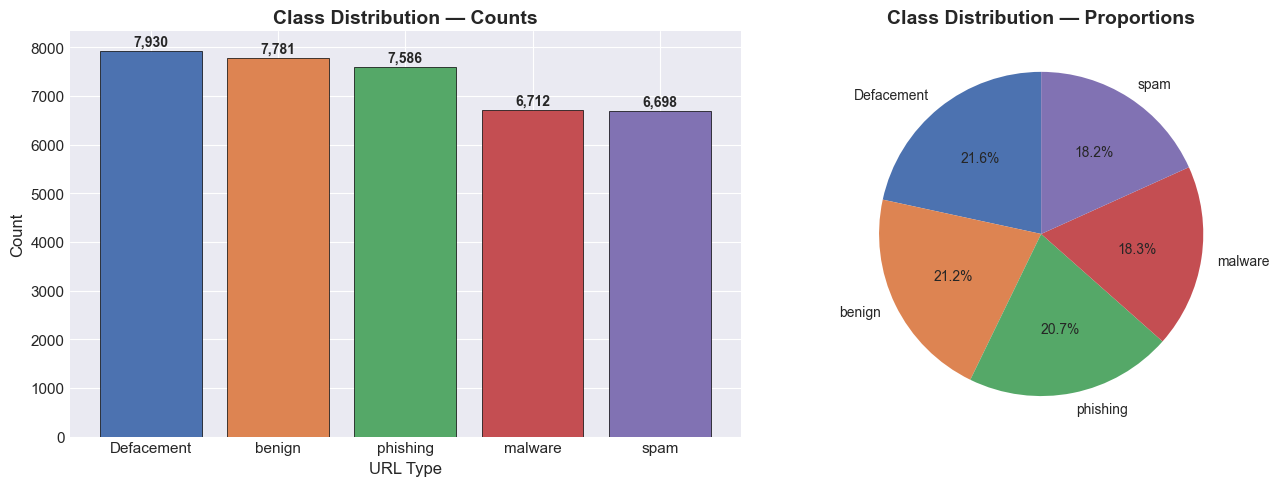

Saved: reports/plots/class_distribution.png


In [14]:
# ============================================================
# Class distribution bar chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — counts
colors = sns.color_palette('deep', n_colors=len(label_counts))
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution — Counts', fontweight='bold')
axes[0].set_xlabel('URL Type')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart — proportions
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Class Distribution — Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/plots/class_distribution.png')

In [15]:
# ============================================================
# Imbalance severity assessment
# ============================================================

ideal_pct = 100.0 / df[LABEL_COL].nunique()
max_deviation = (label_pct - ideal_pct).abs().max()

print(f'Ideal balanced %:     {ideal_pct:.1f}%')
print(f'Max deviation from ideal: {max_deviation:.2f}%')
print(f'Imbalance ratio (max/min): {label_counts.max() / label_counts.min():.3f}')

if label_counts.max() / label_counts.min() > 2.0:
    print('\n⚠️  SIGNIFICANT class imbalance detected — need stratified splits + class weights')
elif label_counts.max() / label_counts.min() > 1.5:
    print('\n⚡ MODERATE class imbalance — stratified splits recommended, class weights optional')
else:
    print('\n✅ Classes are reasonably balanced — stratified splits sufficient')

Ideal balanced %:     20.0%
Max deviation from ideal: 1.75%
Imbalance ratio (max/min): 1.184

✅ Classes are reasonably balanced — stratified splits sufficient


### Step 3 — Decision Output

*(Run the cells above, then fill in)*

- **Number of classes:** 5
- **Imbalance ratio:** ???
- **Imbalance handling needed:** ???
- **Strategy:** Stratified train/test split + class_weight='balanced' in models

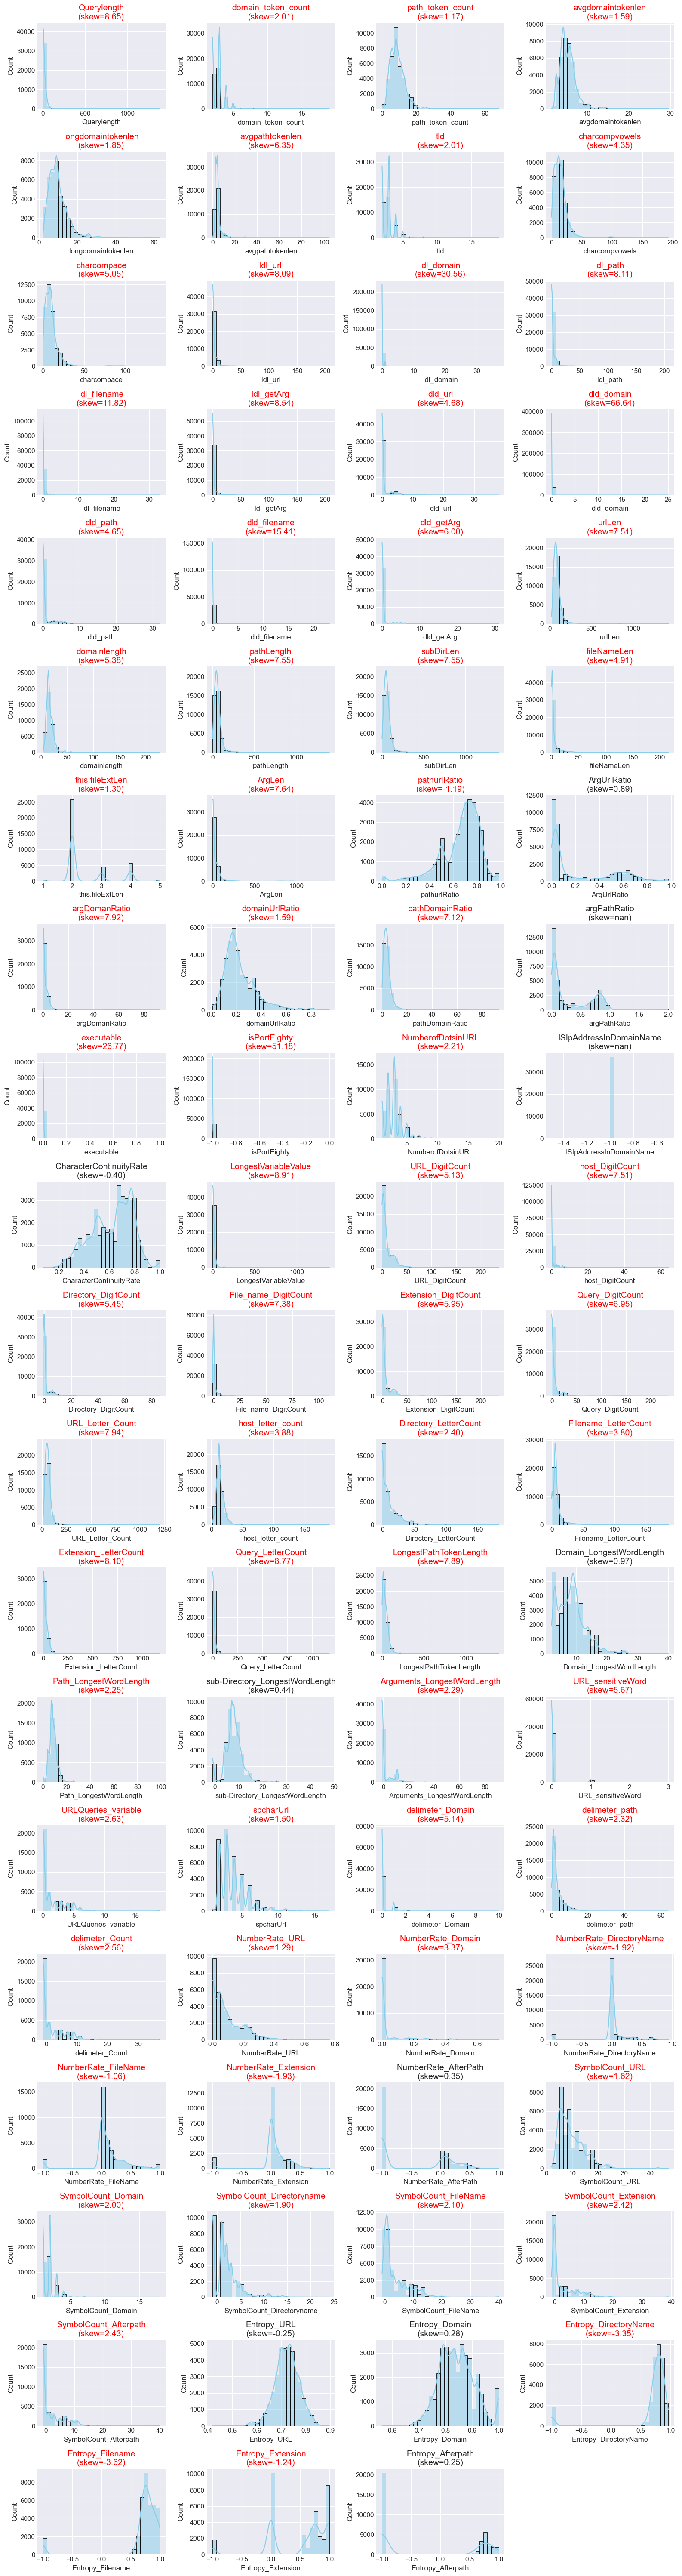

Highly skewed features (|skew| > 1): ['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path', 'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path', 'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL', 'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount', 'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount', 'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count', 'Directory_LetterCount', 'Filename_LetterCount', 'Extension_LetterCount', 'Query_LetterCount', 'LongestPathTokenLength', 'Path_LongestWordLength', 'Arguments_LongestWordLength', 'URL_sensitiveWord', 'URLQueries_variable', 'spcharUrl', 'delimeter_Domain', 'd

In [16]:
# Step 7 — Feature Distribution Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Select numeric features (excluding label/object columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Plot distribution histograms (grid)
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

skewness = {}
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f"{col}")
    # Calculate skewness
    skewness[col] = skew(df[col].dropna())
    # Mark if highly skewed
    if abs(skewness[col]) > 1:
        axes[i].set_title(f"{col}\n(skew={skewness[col]:.2f})", color='red')
    else:
        axes[i].set_title(f"{col}\n(skew={skewness[col]:.2f})")
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# Identify features with high skewness (|skew| > 1)
skewed_features = [col for col, s in skewness.items() if abs(s) > 1]

# Identify features with unusual distributions (bimodal, heavy-tailed) — manual inspection
print("Highly skewed features (|skew| > 1):", skewed_features)
print("Review histograms above for bimodal or heavy-tailed distributions.")

# Suggest transformation candidates
transformation_candidates = skewed_features  # Add more after visual inspection if needed
print("Transformation candidates (log/power):", transformation_candidates)

Feature Distribution Analysis Insights

Out of the total numerical features analyzed, 70+ features exhibited high positive skewness (|skew| > 1). The skewed features were primarily related to URL length metrics, token counts, delimiter frequencies, digit/symbol counts, entropy measures, and query/path statistics.

The observed heavy-tailed distributions indicate the presence of rare but significant anomalous URL patterns, which is consistent with the characteristics of phishing datasets.

These features were identified as potential candidates for logarithmic or power-based transformations during model preprocessing if we are using scaling sensitive models.

For tree based models no such transformations are required.

Saved full correlation matrix CSV: ..\reports\plots\full_correlation_matrix.csv


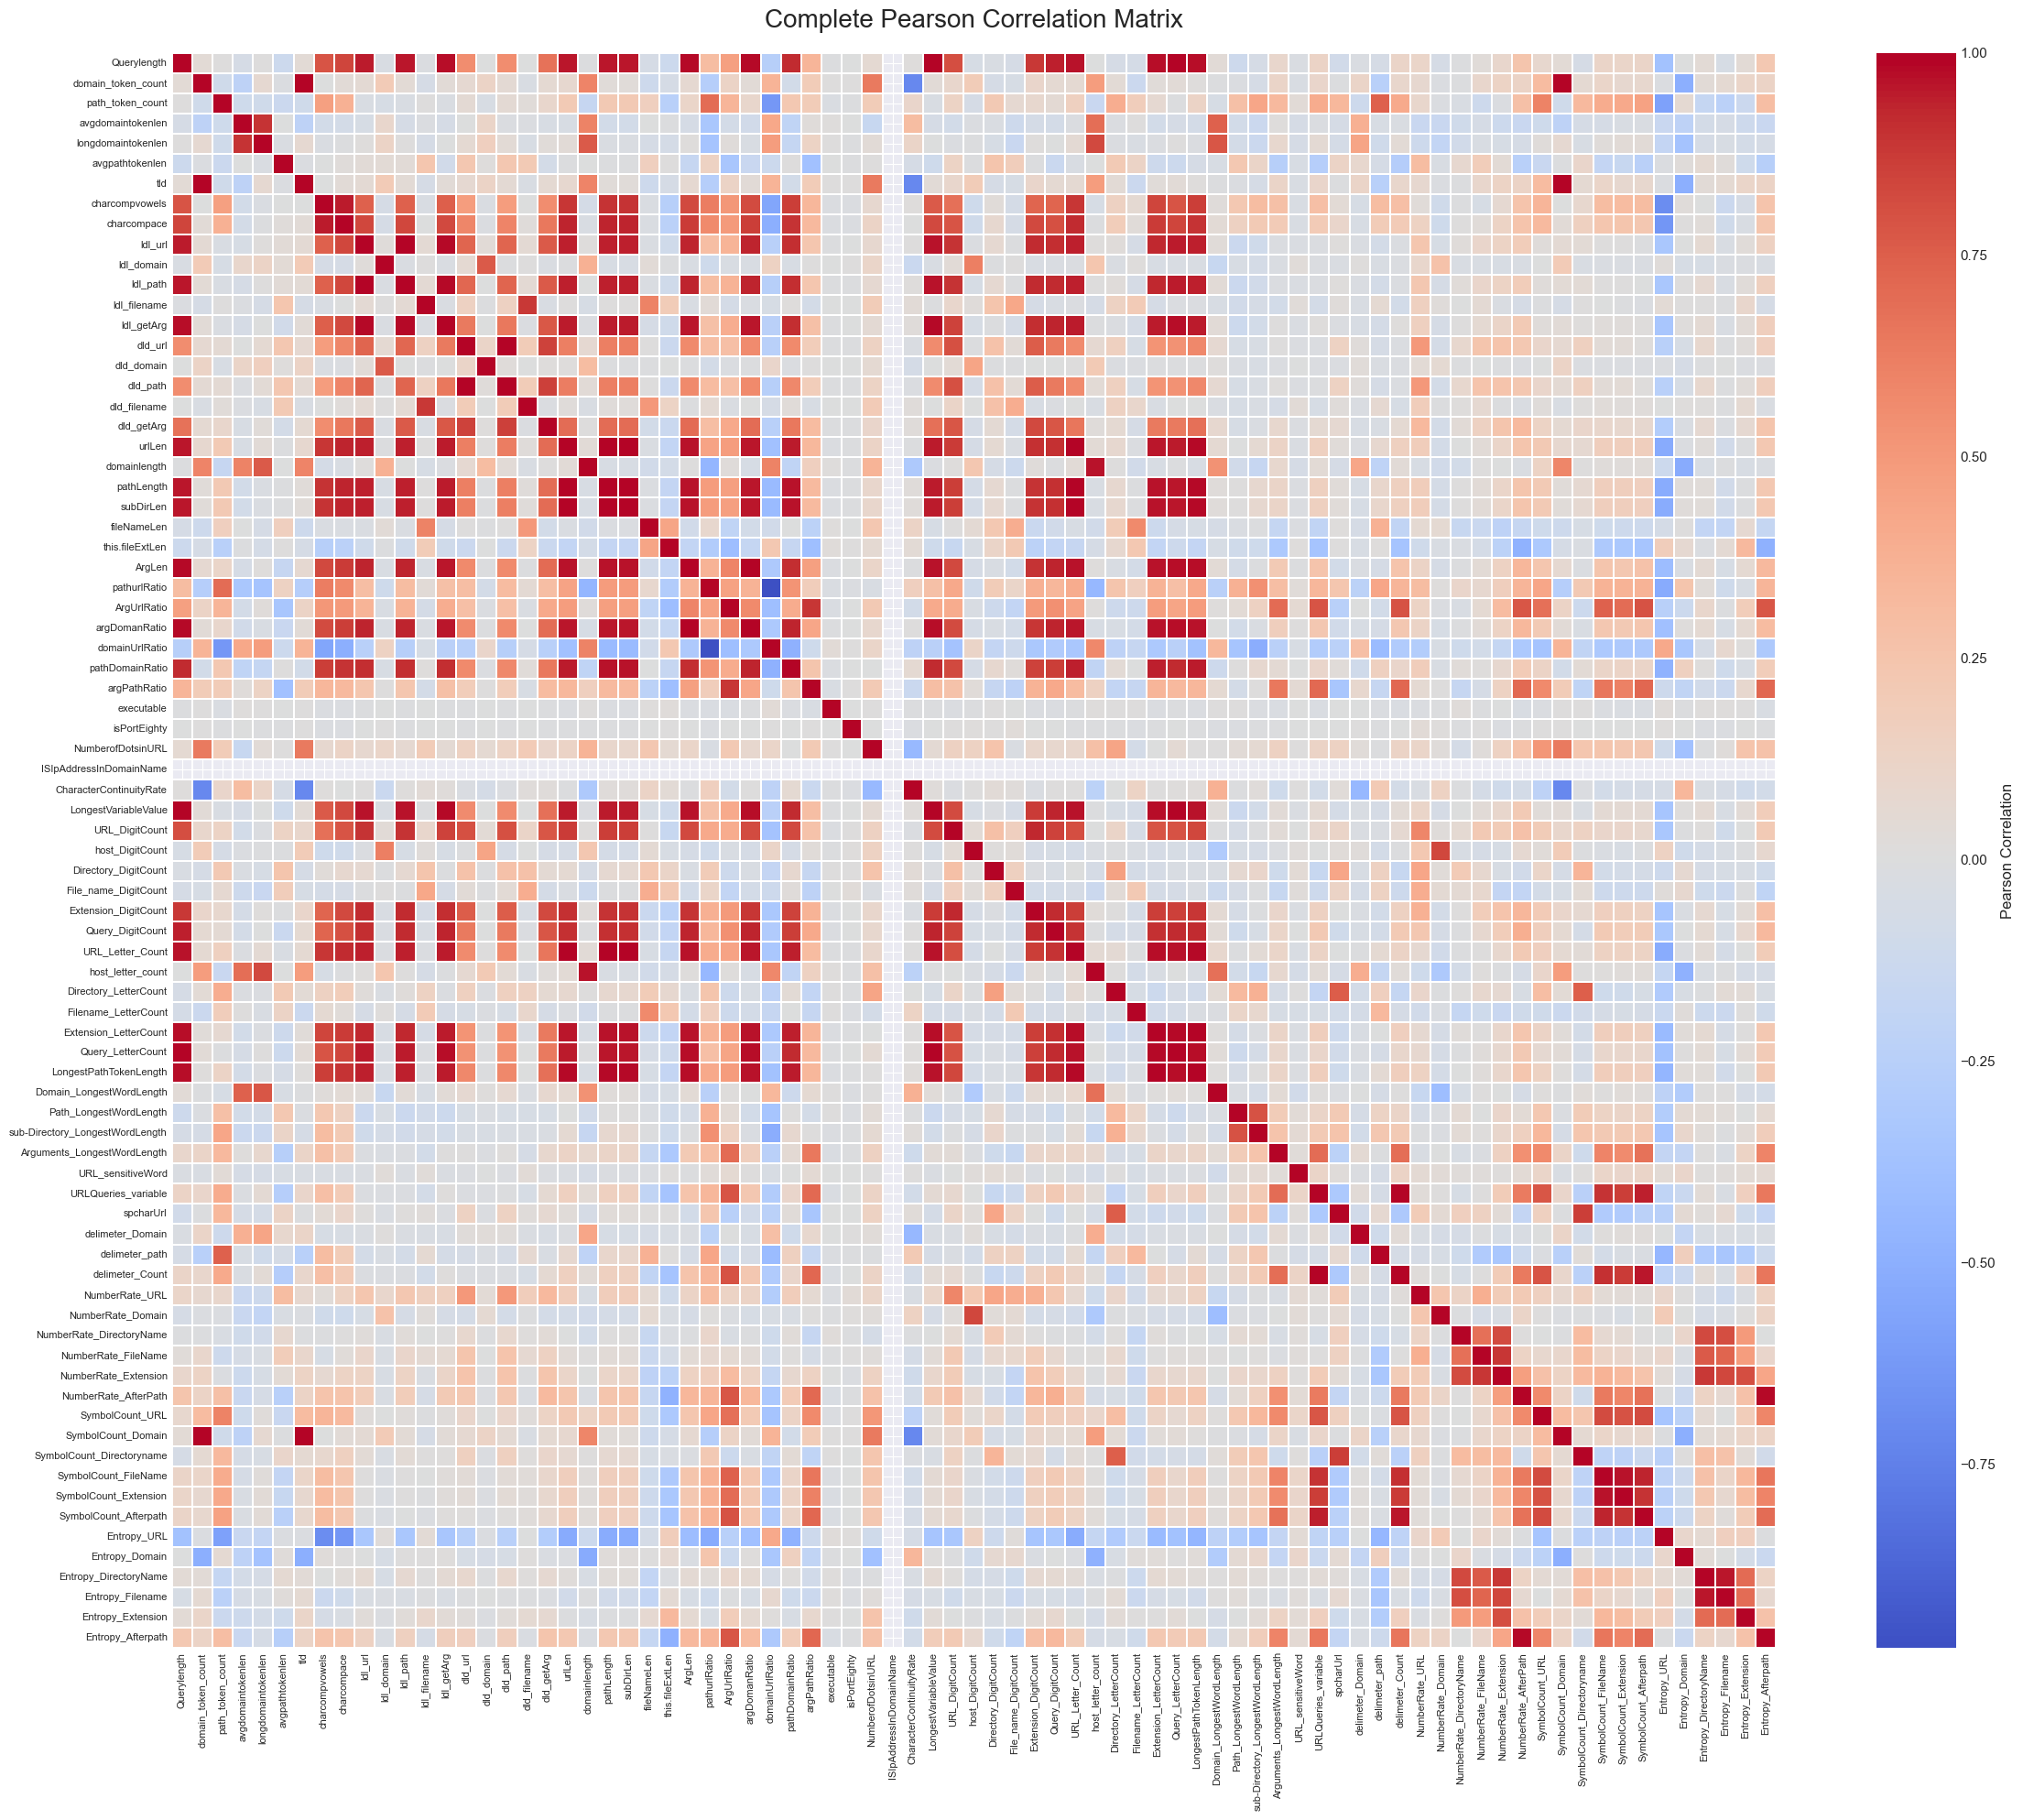

Saved heatmap: ..\reports\plots\complete_correlation_heatmap.png

Highly correlated pairs (|r| > 0.9):

Querylength                         <-> ldl_url                             | r = 0.95
Querylength                         <-> ldl_path                            | r = 0.95
Querylength                         <-> ldl_getArg                          | r = 0.98
Querylength                         <-> urlLen                              | r = 0.96
Querylength                         <-> pathLength                          | r = 0.96
Querylength                         <-> subDirLen                           | r = 0.96
Querylength                         <-> ArgLen                              | r = 0.98
Querylength                         <-> argDomanRatio                       | r = 0.98
Querylength                         <-> pathDomainRatio                     | r = 0.92
Querylength                         <-> LongestVariableValue                | r = 1.00
Querylength               

In [17]:
# Step 9 — Complete Correlation Analysis

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure plots directory exists
os.makedirs(PLOTS_DIR, exist_ok=True)

# Select numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Optional: remove target column
target_col = 'label'   # change if needed
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Compute Pearson correlation matrix
corr_matrix = df[numeric_cols].corr(method='pearson')

# Save full correlation matrix to CSV
corr_csv_path = os.path.join(PLOTS_DIR, 'full_correlation_matrix.csv')
corr_matrix.to_csv(corr_csv_path)

print(f"Saved full correlation matrix CSV: {corr_csv_path}")

# Plot complete heatmap
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    square=False,
    linewidths=0.2,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title(
    'Complete Pearson Correlation Matrix',
    fontsize=20,
    pad=20
)

# Improve label readability
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()

# Save high-resolution figure
heatmap_path = os.path.join(PLOTS_DIR, 'complete_correlation_heatmap.png')

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Saved heatmap: {heatmap_path}")

# Identify highly correlated feature pairs
threshold = 0.90
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]

        r = corr_matrix.iloc[i, j]

        if abs(r) > threshold:
            high_corr_pairs.append((col1, col2, r))

# Print highly correlated pairs
print(f"\nHighly correlated pairs (|r| > {threshold}):\n")

for col1, col2, r in high_corr_pairs:
    print(f"{col1:35s} <-> {col2:35s} | r = {r:.2f}")

print(f"\nTotal highly correlated pairs: {len(high_corr_pairs)}")

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 1. Prepare Binary Label (Malicious vs Benign)
if 'Label' in df.columns:
    # 'benign' is the safe class, everything else is malicious (1)
    y_binary = (df['Label'] != 'benign').astype(int)
else:
    # Fallback in case the label column is named differently
    label_col = df.columns[-1]
    benign_class = df[label_col].value_counts().index[0]
    y_binary = (df[label_col] != benign_class).astype(int)

# 2. Prepare Features
X = df[numeric_cols].copy()

# Replace infinity values with NaN in place
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill all remaining NaNs (including the ones we just created from inf) with -1
X.fillna(-1, inplace=True)

# 3. Train-Test Split for Baseline Metrics
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (29365, 79)
Testing set shape: (7342, 79)


In [22]:
# 4. Train a Baseline Random Forest
print("Training Baseline Random Forest...")
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# 5. Get Baseline Metrics
y_pred = rf_baseline.predict(X_test)

print("\n--- Baseline Model Metrics (Random Forest) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malicious (1)']))


Training Baseline Random Forest...

--- Baseline Model Metrics (Random Forest) ---
Accuracy: 0.9916

               precision    recall  f1-score   support

   Benign (0)       0.99      0.97      0.98      1586
Malicious (1)       0.99      1.00      0.99      5756

     accuracy                           0.99      7342
    macro avg       0.99      0.98      0.99      7342
 weighted avg       0.99      0.99      0.99      7342



In [23]:
# 6. Extract Feature Importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance': rf_baseline.feature_importances_
})

# Sort by importance descending
importance_df = importance_df.sort_values(by='RF_Importance', ascending=False).set_index('Feature')

print("Top 15 Features by Random Forest Importance:")
display(importance_df.head(15))


Top 15 Features by Random Forest Importance:


,RF_Importance
Feature,
Arguments_LongestWordLength,0.0540
avgpathtokenlen,0.0377
spcharUrl,0.0358
SymbolCount_Directoryname,0.0317
argPathRatio,0.0302
urlLen,0.0285
URLQueries_variable,0.0284
SymbolCount_Extension,0.0277
ArgUrlRatio,0.0266
